# I. Data preparation

## Load CIFAR10 dataset

In [145]:
from torchvision import datasets, transforms
import torch

torch.manual_seed(42)

data_path = './../data'

# Define BATCH SIZE = 32
BATCH_SIZE = 128


mean = [0.4914, 0.4822, 0.4465] # Red, Green, Blue means
std = [0.2470, 0.2435, 0.2616]  # Red, Green, Blue standard deviations

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    # transforms.ColorJitter(0.5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.Normalize(mean=mean, std=std),
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


In [146]:
torch.manual_seed(42)
# Load the 2 datasets with different pre-processing methods
train_dataset = datasets.CIFAR10(root=data_path, transform=transform_train, train=True, download=True)
test_dataset = datasets.CIFAR10(root=data_path, transform=transform_val, train=False, download=True)

# Load train and test data using DataLoader
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)


c:\Users\z5719157\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [147]:
tensor_train_data = torch.from_numpy(train_dataset.data)
tensor_train_data = tensor_train_data.to(torch.float)
print(tensor_train_data.dtype)
mean = torch.mean(tensor_train_data / 255, dim=(0, 1, 2))
std = torch.std(tensor_train_data / 255, dim=[0, 1, 2])

print(mean)
print(std)


torch.float32
tensor([0.4914, 0.4822, 0.4465])
tensor([0.2470, 0.2435, 0.2616])


In [111]:
images, labels = next(iter(train_dataloader))
print(images.shape)

torch.Size([256, 3, 32, 32])


In [148]:

imagenet_labels_map = test_dataset.classes
print(f"Number of classes: {len(imagenet_labels_map)}")

Number of classes: 10


In [149]:
import matplotlib.pyplot as plt
torch.manual_seed(42)

def plot_samples(dataset, nrows=3, ncols=3, figname="Train samples"):
    plt.figure(figsize=(3*nrows, 3*ncols))
    # Plot 
    for i in range(1,nrows*ncols+1):
        plt.subplot(nrows, ncols, i)
        random_idx = torch.randint(0, len(dataset), size=[1]).item()
        img = dataset[random_idx][0]
        img_whc = img.permute(1, 2, 0)
        label_num = dataset[random_idx][1]
        plt.imshow(img_whc)
        plt.title(imagenet_labels_map[label_num], fontsize=10)
        
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.8158263].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3644148..1.2906163].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67942464..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..1.9406626].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.44827

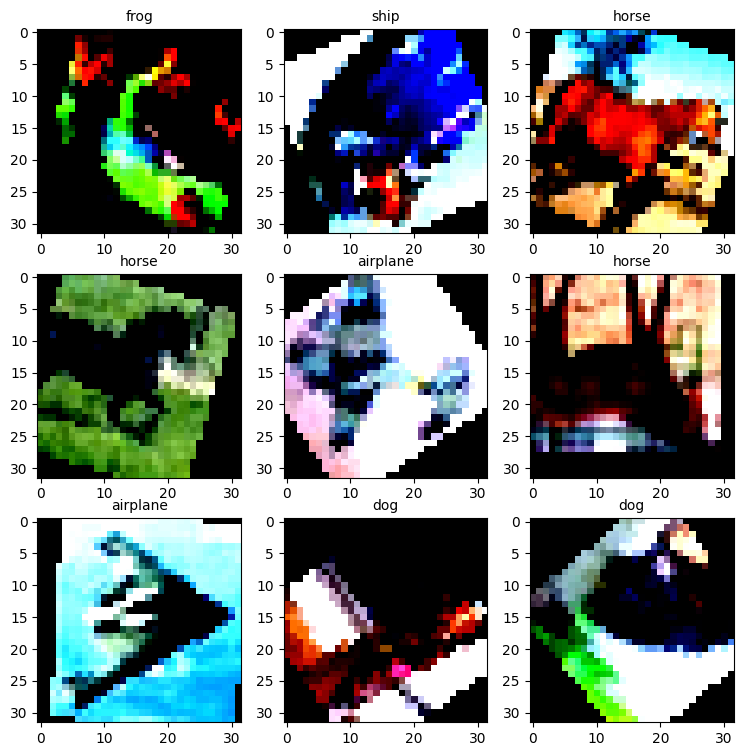

In [150]:
# Plot samples from train dataset
plot_samples(train_dataset_full, figname="Train samples visualization")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0686196..1.6780663].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8836575..1.8759745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8465825..1.7260674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9480774..1.5034215].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.2568185].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8997625..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.957720

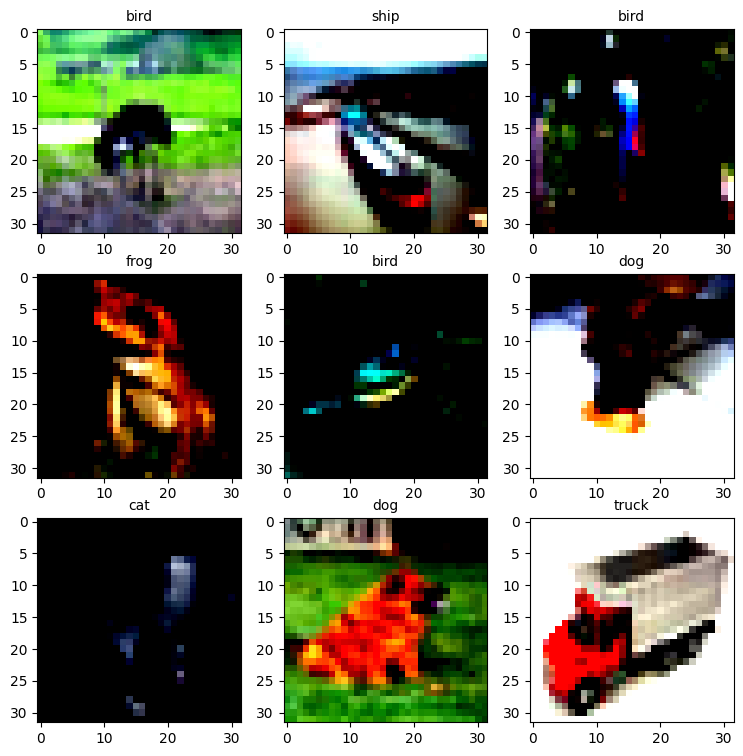

In [151]:
# Plot samples for test dataset
plot_samples(test_dataset, figname="Test samples visualization")

# Build ResNet model using for CIFAR-10 


In [82]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.12.0+cu126


'cuda'

## Custom Normalization

In [83]:
import torch
from torch import nn
import math

**ResNet block**
$$\bold{y} = F(\bold{x}, \{W_i\} + \bold{x} = W_2\sigma(W_1\bold{x})) + \bold{x}$$

In [168]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down_sampling=False):
        super().__init__()
        
        # Determine stride for the first convolution
        stride = 2 if down_sampling else 1
        
        # First layer (downsamples if stride=2)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second layer (always stride=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        
        # Projection shortcut
        self.shortcut = nn.Sequential()
        if down_sampling or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Save input for the skip connection
        identity = self.shortcut(x)
        
        # Main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add skip connection BEFORE the final ReLU
        out += identity
        out = self.relu(out)
        
        return out
    
class ResNet(nn.Module):
    def __init__(self, conv1_channels, conv2_channels, conv3_channels, num_classes=10, depth=2):
        super().__init__()
        self.conv1_channels = conv1_channels
        self.conv2_channels = conv2_channels
        self.conv3_channels = conv3_channels
        self.depth = depth
        self.num_classes = num_classes
        # self.resnet_layer = nn.Sequential(
        #     # Conv 0
        #     nn.Conv2d(in_channels=3, out_channels=self.conv1_channels, kernel_size=7, stride=2, padding=3),
        #     nn.BatchNorm2d(self.conv1_channels),
        #     nn.ReLU(inplace=True),
        #     nn.MaxPool2d(kernel_size=3, stride=2)
        # )
        self.stem = nn.Sequential(
            nn.Conv2d(3, self.conv1_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(self.conv1_channels),
            nn.ReLU(inplace=True)
        )
            
            # Conv 2 x 2
        self.conv1_list = [ResNetBlock(in_channels=self.conv1_channels, out_channels=self.conv1_channels, down_sampling=False) for i in range(2*depth)]
        self.conv1_stack = nn.ModuleList(self.conv1_list)
            # Conv 3 x 2
        self.conv2_list = [ResNetBlock(in_channels=self.conv1_channels, out_channels=self.conv2_channels, down_sampling=True)]
        for i in range(2*depth - 1):
            self.conv2_list.append(ResNetBlock(in_channels=self.conv2_channels, out_channels=self.conv2_channels, down_sampling=False))
        self.conv2_stack = nn.ModuleList(self.conv2_list)
            # Conv 4 x 2
        self.conv3_list = [ResNetBlock(in_channels=self.conv2_channels, out_channels=self.conv3_channels, down_sampling=True)]
        for i in range(2*depth - 1):
            self.conv3_list.append(ResNetBlock(in_channels=self.conv3_channels, out_channels=self.conv3_channels, down_sampling=False))
        self.conv3_stack = nn.ModuleList(self.conv3_list)


        self.dense_layer = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_features=self.conv3_channels, out_features=self.num_classes),
        )
    
    def forward(self, X):
        out = self.stem(X)
        # Conv 1: 2n stacked layer, no down_sampling
        for i in range(2 * self.depth):
            out = self.conv1_stack[i](out)
        
        # Conv 2: 1 downsample convolution layer and 2n-1 consitent dimensions convolution layer
        for i in range(2 * self.depth):
            out = self.conv2_stack[i](out)

        # Conv 3: 1 downsample convolution layer and 2n-1 consitent dimensions convolution layer
        for i in range(2 * self.depth):
            out = self.conv3_stack[i](out)

        out = self.dense_layer(out)
        
        return out
        

In [169]:
X = torch.rand([3, 3, 3, 3])
X.shape[0]

3

## ResNetV1

In [170]:
model = ResNet(16, 32, 64, num_classes=10, depth=10)
model

ResNet(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv1_stack): ModuleList(
    (0-19): 20 x ResNetBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
  )
  (conv2_stack): ModuleList(
    (0): ResNetBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, tra

## Prepare Loss function, optimizer, learning rate
- **Loss function**: CrossEntropyLoss
- **Optimizer**: Stochastic Gradient Descent (SGD)
- **Learning rate scheduler**: Reduce Learning Rate on Plateau 


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', 0.1, patience=10, min_lr=0.00001)

In [ ]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## Create training loop
- Total number of epochs: 1000
- Define training step function
- Define test step function

In [172]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device):
    model.train()
    model.to(device)
    train_loss = 0
    train_acc = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true = y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (batch % 50 == 0):
            print(f"Training batch {batch} / {len(dataloader)}")
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    print(f"Train loss: {train_loss} | Train acc: {train_acc}")
    return train_loss, train_acc
    
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device="cpu"):
    model.to(device)
    model.eval()
    test_loss = 0
    test_acc = 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
            if (batch % 200 == 0):
                print(f"Testing batch {batch} / {len(dataloader)}")
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
    print(f"Test loss: {test_loss} | Test acc: {test_acc}")
    return test_loss, test_acc



In [ ]:
# Training loop
epochs = 1000
hist = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
print("Log history: ", hist.keys())

for epoch in range(epochs): 
    print(f"========= Epoch [{epoch+1}/{epochs}] with lr = {optimizer.param_groups[0]['lr']} =========")
    train_loss, train_acc = train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device='cuda'
    )

    scheduler.step(train_loss)

    test_loss, test_acc = test_step(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device='cuda'
    )

    hist["train_loss"].append(train_loss)
    hist["train_acc"].append(train_acc)
    hist["test_loss"].append(test_loss)
    hist["test_acc"].append(test_acc)

    

cuda
Log history:  dict_keys(['train_loss', 'test_loss', 'train_acc', 'test_acc'])
========= Epoch [1/1000] with lr = 0.1 =========
Training batch 0 / 391
Training batch 50 / 391
Training batch 100 / 391
Training batch 150 / 391
Training batch 200 / 391
Training batch 250 / 391
Training batch 300 / 391
Training batch 350 / 391
Train loss: 2.0636710004733345 | Train acc: 20.31929347826087
Testing batch 0 / 79
Test loss: 1.9376876806911034 | Test acc: 24.930775316455698
========= Epoch [2/1000] with lr = 0.1 =========
Training batch 0 / 391
Training batch 50 / 391
Training batch 100 / 391
Training batch 150 / 391
Training batch 200 / 391
Training batch 250 / 391
Training batch 300 / 391
Training batch 350 / 391
Train loss: 1.9110869931442964 | Train acc: 26.405450767263428
Testing batch 0 / 79
Test loss: 1.8518531443197517 | Test acc: 29.93473101265823
========= Epoch [3/1000] with lr = 0.1 =========
Training batch 0 / 391
Training batch 50 / 391
Training batch 100 / 391
Training batch 1

## Plot val train loss history 

<class 'list'>
<class 'list'>
[1.9376876806911034, 1.8518531443197517, 1.801678959327408, 1.6472512574135503, 1.7719398706774168, 1.7096382319172727, 1.4401720747163025, 1.6863195850879331, 1.1158158454713942, 1.092366631272473, 1.1199291401271578, 1.1565296483945242, 1.0939951720117014, 1.7669818220259268, 1.4374112916898123, 1.2206087225600133, 0.9713692619830747, 1.1374869444702245, 1.0147097812423223, 1.0000865972494777, 0.9804012066201319, 0.9803498915479153, 0.9967886488648909, 1.0164615345906607, 0.9521727297879472, 0.8098428536065018, 0.8436284095426149, 0.9135174728647063, 0.8603376806536808, 1.0687803980670398, 0.9336818102039869, 0.8331781550298764, 1.5205271862730194, 1.1607457354098936, 0.7784650650205491, 0.92548171251635, 1.2637488147880458, 1.359964345074907, 1.1578425153901306, 0.773230800145789, 0.7115926882134208, 1.0770570899866805, 0.7530348587639725, 0.9692345751991754, 0.6881987229932712, 0.7870585710941991, 0.8676778025264982, 0.936952513984487, 0.88242175533801

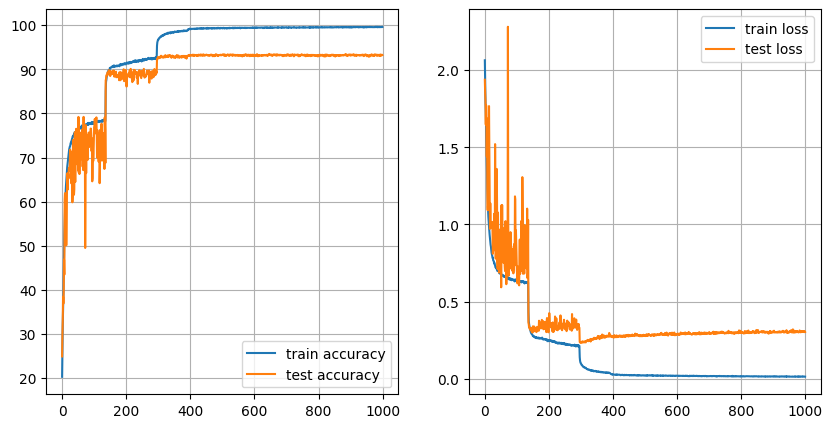

In [192]:
import numpy as np

print(type(hist['train_acc']))
print(type(hist['test_loss']))

print(hist['test_loss'])
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(np.array(hist['train_acc']), label='train accuracy')
plt.plot(np.array(hist['test_acc']), label='test accuracy')
plt.grid(visible=1)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.array(hist['train_loss']), label='train loss')
plt.plot(np.array(hist['test_loss']), label='test loss')
plt.grid(visible=1)
plt.legend()
plt.show()


## Visualize model predictions

In [194]:
torch.manual_seed(42)

def plot_predictions(dataset, nrows, ncols, model):
    plt.figure(figsize=(4*nrows, 4*ncols))
    # Plot 
    with torch.inference_mode():
        for i in range(1,nrows*ncols+1):
            
            plt.subplot(nrows, ncols, i)
            
            model.to('cpu')
            model.eval()

            random_idx = torch.randint(0, len(dataset), size=[1]).item()
            img = dataset[random_idx][0]
            
            # Ground truth
            img_whc = img.permute(1, 2, 0)
            label_num = dataset[random_idx][1]
            
            # Predict value
            pred_label = torch.softmax(model(img.unsqueeze(dim=0)), dim=1).argmax(dim=1).item()
        
            plt.imshow(img_whc)
            if pred_label == label_num:
                plt.title(f"Ground truth: {imagenet_labels_map[label_num]} | Prediction: {imagenet_labels_map[pred_label]}", fontsize=10, c='g')
            else:
                plt.title(f"Ground truth: {imagenet_labels_map[label_num]} | Prediction: {imagenet_labels_map[pred_label]}", fontsize=10, c='r')
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.656061..2.0620687].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..1.9209466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9418434..1.8527037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8675525..1.2176392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8353425..2.0137537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.3213184].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8353425

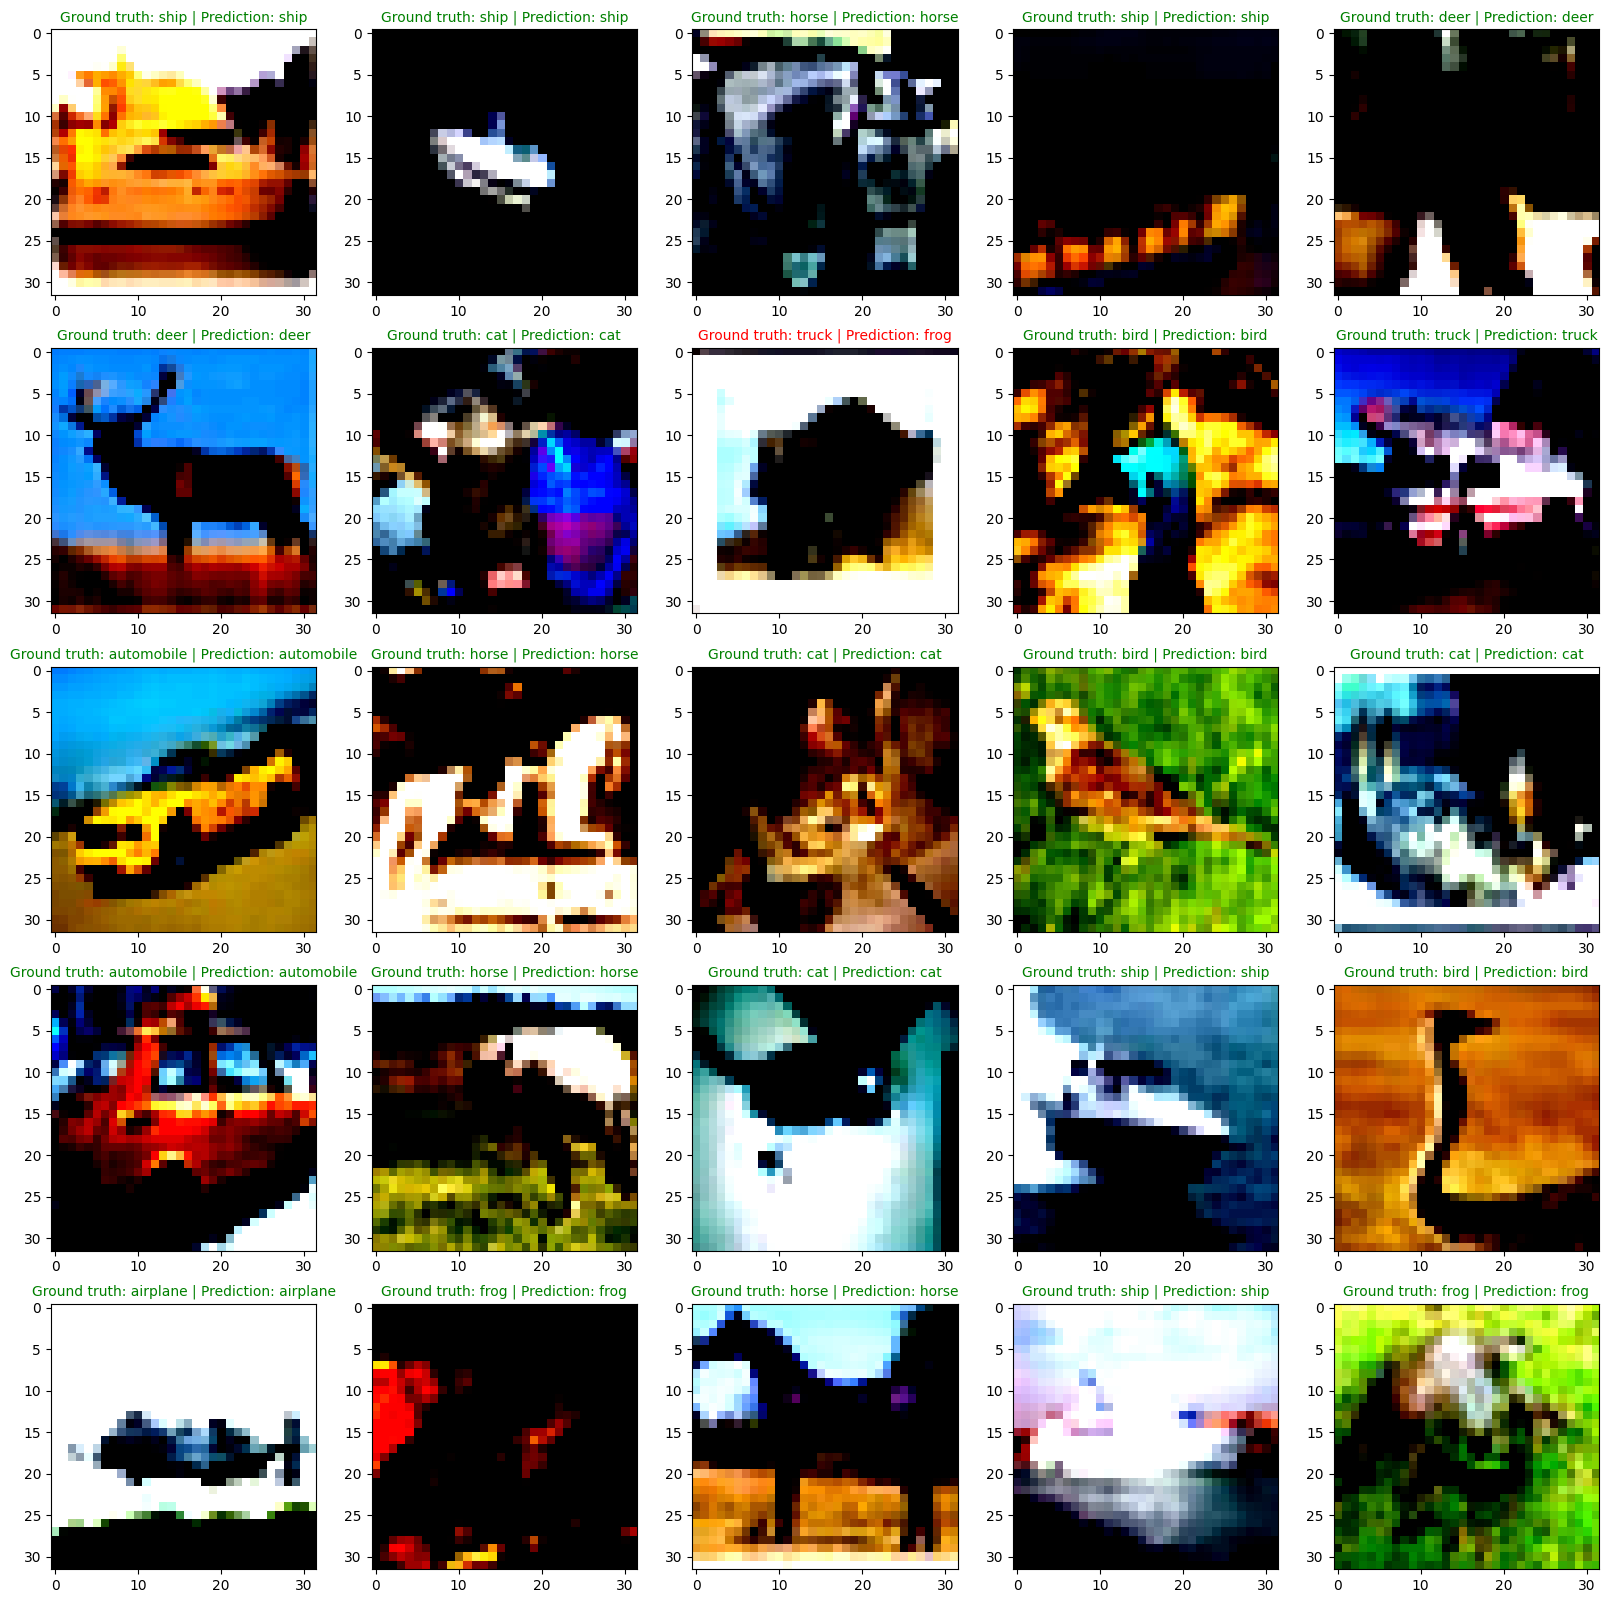

In [197]:
plot_predictions(test_dataset, 5, 5, model)

## Save model

In [196]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("saved_models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model saved path
MODEL_NAME = "ResNetV1_10.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: saved_models\ResNetV1_10.pth


## Test save model

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0858443].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6742924..1.074748].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8675525..1.7560488].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.8527037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..2.0708537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5131699..1.6304358].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.656061.

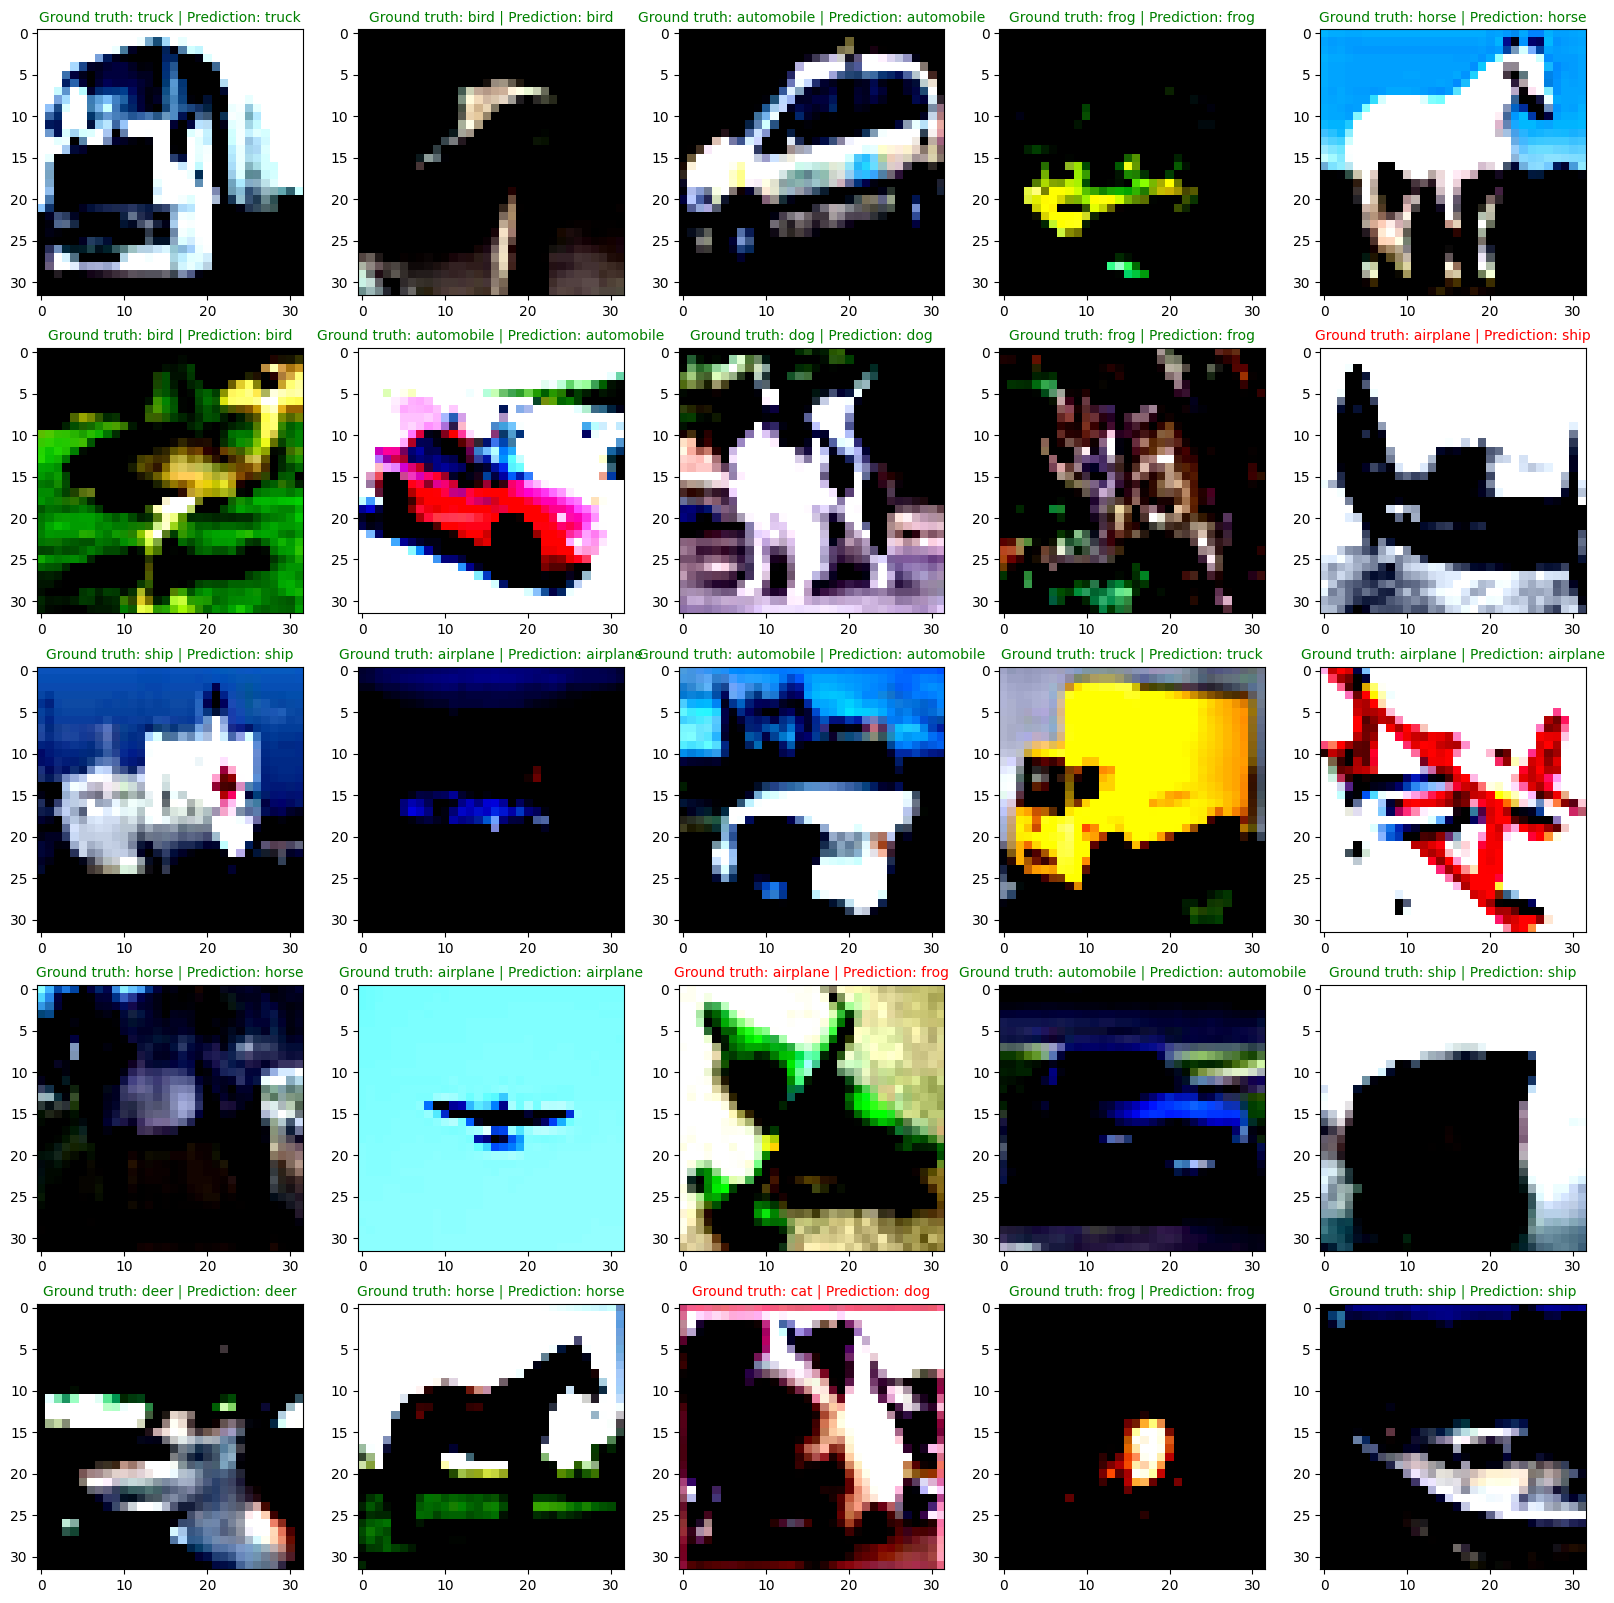

In [200]:
# Instantate a new instance of our model
loaded_model = ResNet(16, 32, 64, num_classes=10, depth=10)

# Load the state_dict of our saved model
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Test loaded model
torch.manual_seed(1234)
plot_predictions(test_dataset, 5, 5, loaded_model)